In [42]:
from pathlib import Path
from typing import Union, List, Iterable
import re
import shutil

import numpy as np
import cv2
import pywt

from numpy.fft import fftshift, fftfreq
import matplotlib.pyplot as plt
import pandas as pd
import os

from scipy.signal import find_peaks

In [44]:
def load_gray(path: Union[str, Path]) -> np.ndarray:
    """
    Load an image as float32 grayscale array (0-255).
    """
    p = Path(path)
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {p}")

    h_pp, w_pp = img.shape

    fig, ax = plt.subplots()
    extent = [0, h_pp, w_pp, 0]     
    ax.imshow(img, cmap="gray", extent=extent)
    ax.set_xlabel("pixels"); ax.set_ylabel("pixels")
    ax.set_title("Pre-processed frame")
    ax.set_aspect("equal")

    plt.tight_layout()
        
    return img.astype(np.float32), fig
    

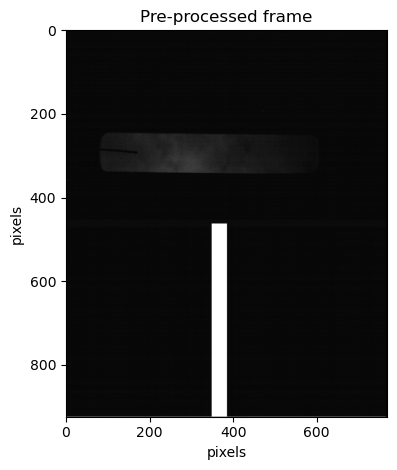

In [46]:
image = r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\Schlieren post processing\Schlieren data\260217\1us_1000fps_background_realign\1us_1000fps_background_realign 002.tif"

img, fig = load_gray(image)

In [47]:
def fft2_psd(img: np.ndarray, *, detrend: bool = True, window: bool = True):
    """
    Compute centered 2D FFT and PSD.
    Returns:
      Fshift (complex), psd (float), psd_log (float)
    """
    x = img.astype(np.float32)

    # optional: remove DC + slow gradients (helps peaks stand out)
    if detrend:
        x = x - np.mean(x)

    # optional: window to reduce leakage (recommended for peak detection)
    if window:
        wy = np.hanning(x.shape[0]).astype(np.float32)
        wx = np.hanning(x.shape[1]).astype(np.float32)
        w2d = wy[:, None] * wx[None, :]
        x = x * w2d

    F = np.fft.fft2(x)
    Fshift = np.fft.fftshift(F)

    psd = (np.abs(Fshift) ** 2).astype(np.float32)
    psd_log = np.log1p(psd)

    return Fshift, psd, psd_log


def show_psd(psd_log, title):
    H, W = psd_log.shape

    fx = np.fft.fftshift(np.fft.fftfreq(W))
    fy = np.fft.fftshift(np.fft.fftfreq(H))

    plt.figure(figsize=(6,5))
    plt.imshow(
        psd_log,
        extent=[fx[0], fx[-1], fy[-1], fy[0]],
        cmap="gray"
    )
    plt.xlabel("kx (cycles/pixel)")
    plt.ylabel("ky (cycles/pixel)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

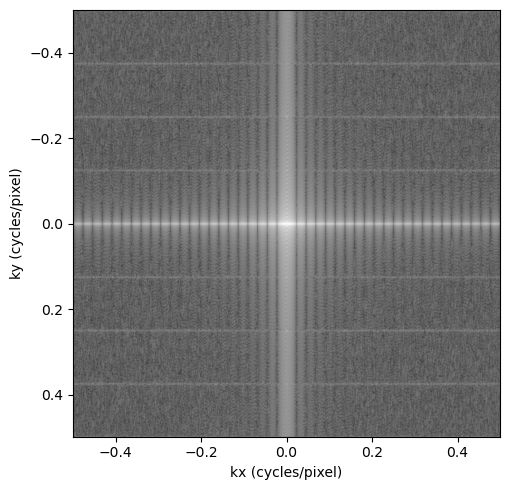

In [50]:
Fshift, psd, psd_log = fft2_psd(img)
show_psd(psd_log, title=None)

In [51]:
def ky_1d_spectrum(psd: np.ndarray, *, collapse: str = "mean"):
    """
    Return 1D spectrum vs ky (cycles/pixel) by collapsing 2D PSD over kx.

    Returns:
      ky (float array, cycles/pixel, fftshifted so 0 is centered),
      spec (float array, collapsed PSD)
    """
    # Collapse over kx to get spectrum vs ky
    collapse = collapse.lower().strip()
    if collapse == "mean":
        spec = psd.mean(axis=1)
    elif collapse == "sum":
        spec = psd.sum(axis=1)
    else:
        raise ValueError("collapse must be 'mean' or 'sum'")

    # ky axis in cycles/pixel (fftshifted to match psd shift)
    H = img.shape[0]
    ky = np.fft.fftshift(np.fft.fftfreq(H, d=1.0))  # cycles per pixel

    return ky, spec


def plot_ky_spectrum(ky: np.ndarray, spec: np.ndarray, *, log: bool = True, title: str = "Collapsed PSD vs ky"):
    """
    Plot collapsed PSD vs ky in cycles/pixel.
    """
    y = np.log1p(spec) if log else spec

    plt.figure(figsize=(10, 3.5))
    plt.plot(ky, y)
    plt.xlabel("ky (cycles/pixel)")
    plt.ylabel("log(1 + PSD)" if log else "PSD")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

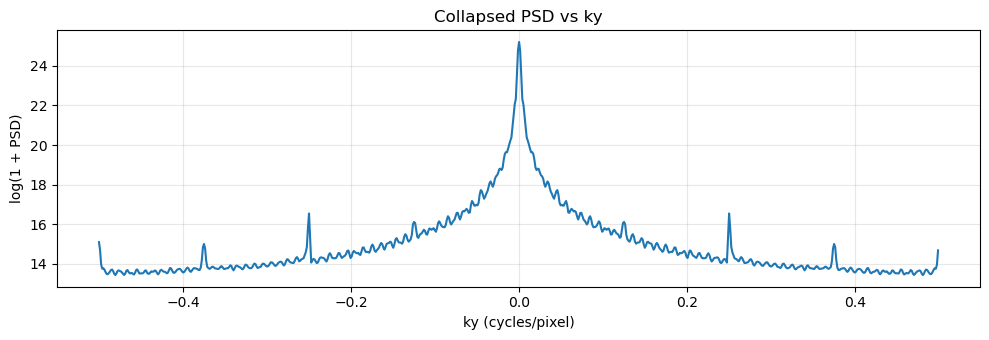

In [54]:
ky, spec = ky_1d_spectrum(psd, collapse="mean")
plot_ky_spectrum(ky, spec, log=True)

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def find_and_plot_ky_peaks(
    ky: np.ndarray,
    spec: np.ndarray,
    *,
    log: bool = True,
    title: str = "Collapsed PSD vs ky with peaks",
    exclude_dc_cycpix: float = 0.1,     # ignore |ky| < this (cycles/pixel)
    prominence: float | None = None,     # tune this first if you get too many peaks
    height: float | None = None,         # alternative to prominence
    distance: int | None = 10,           # min spacing in samples (bins)
    max_peaks: int | None = 10,          # keep only top-N by prominence
    annotate_period: bool = True,
):
    """
    Find peaks in the ky spectrum and label them on the plot.
    """
    y = np.log1p(spec) if log else spec

    # mask out DC neighborhood
    dc_mask = np.abs(ky) < exclude_dc_cycpix
    y_work = y.copy()
    y_work[dc_mask] = -np.inf

    peaks, props = find_peaks(
        y_work,
        prominence=prominence,
        height=height,
        distance=distance,
    )

    # Optionally keep only the strongest N peaks (by prominence if available, else by height)
    if max_peaks is not None and len(peaks) > max_peaks:
        if "prominences" in props and props["prominences"] is not None:
            order = np.argsort(props["prominences"])[::-1]
        else:
            order = np.argsort(y_work[peaks])[::-1]
        keep = order[:max_peaks]
        peaks = peaks[keep]
        # also trim props arrays consistently
        for k, v in props.items():
            if isinstance(v, np.ndarray) and v.shape[0] == len(order):
                props[k] = v[keep]

    # Plot
    plt.figure(figsize=(10, 3.5))
    plt.plot(ky, y, label="spectrum")
    plt.plot(ky[peaks], y[peaks], "rx", label="peaks")

    # Annotate peaks
    for i, p in enumerate(peaks):
        k0 = ky[p]
        label = f"{i}: {k0:.4f}"
        if annotate_period and k0 != 0:
            period_px = 1.0 / abs(k0)
            label += f"\n({period_px:.1f}px)"
        plt.annotate(
            label,
            (k0, y[p]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=9,
            color="red"
        )

    plt.xlabel("ky (cycles/pixel)")
    plt.ylabel("log(1 + PSD)" if log else "PSD")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

    # Return peak locations and some useful info
    peak_info = []
    for idx, p in enumerate(peaks):
        k0 = float(ky[p])
        info = {
            "index": int(p),
            "ky_cyc_per_px": k0,
            "value": float(y[p]),
        }
        if annotate_period and k0 != 0:
            info["period_px"] = float(1.0 / abs(k0))
        peak_info.append(info)

    return peak_info, peaks, props

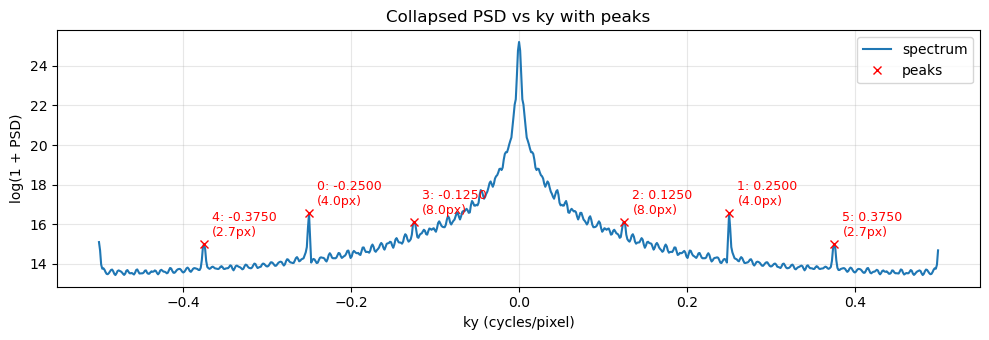

[{'index': 192,
  'ky_cyc_per_px': -0.25,
  'value': 16.539281845092773,
  'period_px': 4.0},
 {'index': 576,
  'ky_cyc_per_px': 0.25,
  'value': 16.539281845092773,
  'period_px': 4.0},
 {'index': 480,
  'ky_cyc_per_px': 0.125,
  'value': 16.110321044921875,
  'period_px': 8.0},
 {'index': 288,
  'ky_cyc_per_px': -0.125,
  'value': 16.110321044921875,
  'period_px': 8.0},
 {'index': 96,
  'ky_cyc_per_px': -0.375,
  'value': 14.996438026428223,
  'period_px': 2.6666666666666665},
 {'index': 672,
  'ky_cyc_per_px': 0.375,
  'value': 14.996437072753906,
  'period_px': 2.6666666666666665}]

In [58]:
peak_info, peaks, props = find_and_plot_ky_peaks(
    ky, spec,
    log=True,
    exclude_dc_cycpix=0.1,
    prominence=0.2,   # tune depending on your data
    distance=8,
    max_peaks=6,
)
peak_info

In [60]:
def make_ky_bandstop_mask(
    shape: tuple[int, int],
    ky_targets: list[float],
    *,
    sigma_ky: float = 0.005,   # cycles/pixel: thickness of the removed band
):
    """
    Build multiplicative FFT mask that removes energy at ky = ±k0 for ALL kx.
    Works in fftshifted coordinates.

    ky_targets: list of ky frequencies in cycles/pixel (positive numbers recommended).
    sigma_ky: Gaussian std dev of notch in ky (cycles/pixel).

    Returns:
      mask (float32), 1=keep, 0~remove at the ky bands
    """
    H, W = shape
    ky = np.fft.fftshift(np.fft.fftfreq(H, d=1.0))  # cycles/pixel
    KY = ky[:, None]  # shape (H, 1), broadcasts across W

    mask = np.ones((H, W), dtype=np.float32)

    for k0 in ky_targets:
        k0 = float(abs(k0))
        if k0 < 1e-12:
            continue

        # Gaussian "bumps" along ky only (applies for all kx)
        g_pos = np.exp(-0.5 * ((KY - k0) / sigma_ky) ** 2)
        g_neg = np.exp(-0.5 * ((KY + k0) / sigma_ky) ** 2)

        notch = (1.0 - g_pos) * (1.0 - g_neg)  # shape (H,1)
        mask *= notch.astype(np.float32)        # broadcasts to (H,W)

    return mask

In [62]:
def ky_bandstop_filter_image(
    img: np.ndarray,
    ky_targets: list[float],
    *,
    sigma_ky: float = 0.002,
    detrend: bool = False,
):
    """
    Remove selected ky frequencies for all kx using FFT bandstop.
    Returns:
      filtered image (float32), mask (float32)
    """
    x = img.astype(np.float32)
    if detrend:
        x = x - np.mean(x)

    F = np.fft.fft2(x)
    Fshift = np.fft.fftshift(F)

    mask = make_ky_bandstop_mask(x.shape, ky_targets, sigma_ky=sigma_ky)
    Ffilt = Fshift * mask

    out = np.fft.ifft2(np.fft.ifftshift(Ffilt))
    out = np.real(out).astype(np.float32)
    return out, mask

def save_uint8_tif_fixed_scale(
    img: np.ndarray,
    out_path: Union[str, Path],
    *,
    vmin: float=0,
    vmax: float=255,
) -> Path:
    """
    Save as 8-bit TIFF with fixed linear mapping vmin->0, vmax->255.
    Best for consistent appearance across many frames.
    """
    out_path = Path(out_path)
    if out_path.suffix == "":
        out_path = out_path.with_suffix(".tif")
    out_path.parent.mkdir(parents=True, exist_ok=True)

    x = img.astype(np.float32)
    if vmax - vmin < 1e-9:
        raise ValueError("vmax must be > vmin")

    x8 = (x - vmin) * (255.0 / (vmax - vmin))
    x8 = np.clip(x8, 0, 255).astype(np.uint8)

    ok = cv2.imwrite(str(out_path), x8)
    if not ok:
        raise IOError(f"Failed to write 8-bit TIFF to: {out_path}")

    print(f"Saved 8-bit TIFF: {out_path}")
    return out_path

In [101]:
filtered, mask = ky_bandstop_filter_image(
    img,
    ky_targets=[0.125,0.25, 0.375, 0.5],
    sigma_ky=2/img.shape[0],
)

save_uint8_tif_fixed_scale(
    filtered,
    r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\Schlieren post processing\Schlieren data\260217\1us_1000fps_background_realign\FILTERED"  # no extension ok
)

Saved 8-bit TIFF: C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\Schlieren post processing\Schlieren data\260217\1us_1000fps_background_realign\FILTERED.tif


WindowsPath('C:/Users/ahada/OneDrive/University of Washington/Z-Pinch Fusion/Schlieren post processing/Schlieren data/260217/1us_1000fps_background_realign/FILTERED.tif')

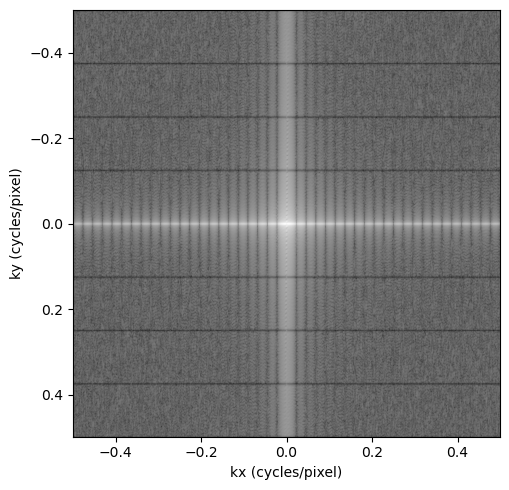

In [103]:
Fshift, psd, psd_log = fft2_psd(filtered)
show_psd(psd_log, title=None)

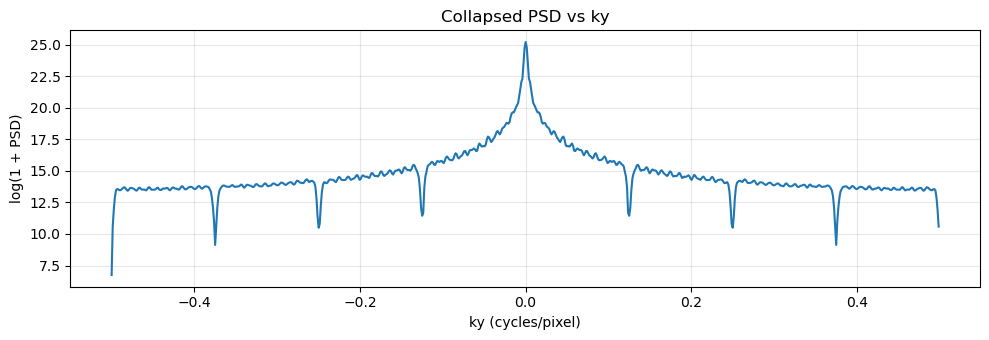

In [104]:
ky, spec = ky_1d_spectrum(psd, collapse="mean")
plot_ky_spectrum(ky, spec, log=True)